## Data Collection

For this project (for both BTC and NASDAQ):

- **Interval:** 1-minute
- **Date range:** 1/12/2025 00:00 - 5/12/2025 23:00 

## BTC/USDT perpetual futures

Historical 1-minute BTC/USDT perpetual futures data were obtained from **Binance** using the **Python Binance API**.  

The code connects to Binance’s futures API and downloads 1-minute candlestick data (`futures_historical_klines`) for the specified date range. Each candlestick includes:

- Open, High, Low, Close prices  
- Trading volume and quote volume  
- Number of trades  
- Taker buy volumes  

In [ ]:
from binance.client import Client
import pandas as pd
import datetime

# Binance API credentials
api_key = 'PASTE YOURS :)'
api_secret = 'PASTE YOURS :)'

client = Client(api_key, api_secret)

# Define the symbol for BTC/USDT pair
symbol = 'BTCUSDT'

# Define custom start and end time
start_time = datetime.datetime(2025, 10, 14, 0, 0, 0)
end_time = datetime.datetime(2025, 10, 21, 0, 0, 0)

klines = client.futures_historical_klines(symbol=symbol, interval=Client.KLINE_INTERVAL_1MINUTE, start_str=str(start_time), end_str=str(end_time))

# Convert the data into a pandas dataframe for easier manipulation
df_M = pd.DataFrame(klines, columns=['Open Time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close Time', 'Quote Asset Volume', 'Number of Trades', 'Taker Buy Base Asset Volume', 'Taker Buy Quote Asset Volume', 'Ignore'])


columns_to_convert = ['Open', 'High', 'Low', 'Close', 'Volume', 'Quote Asset Volume', 'Number of Trades', 'Taker Buy Base Asset Volume', 'Taker Buy Quote Asset Volume']

for col in columns_to_convert:
    df_M[col] = df_M[col].astype(float)

df_M

## Data Preprocessing

After downloading the raw data, preprocessing was performed in Python (Pandas):

1. Converted numeric columns from strings to floats for analysis  
2. Converted timestamps to **EST/NYC** timezone  

*NOTE:*(All datasets were converted from UTC to EST timezone - Binance always provides historical data in UTC) 

3. Constructed three datasets for the analysis:
   - **Full dataset**  
   - **Weekday dataset** 
   - **New York session dataset** 
   

In [ ]:
import pandas as pd
import datetime
import pytz

# Convert timestamps from UTC to New York timezone (EST) (handles DST automatically)
ny_tz = pytz.timezone('America/New_York')
df_M['Open Time'] = pd.to_datetime(df_M['Open Time'], unit='ms', utc=True).dt.tz_convert(ny_tz)
df_M['Close Time'] = pd.to_datetime(df_M['Close Time'], unit='ms', utc=True).dt.tz_convert(ny_tz)

# Construct datasets

# 1. Full dataset
df_full = df_M.copy()

# 2. Weekday dataset (exclude weekends only)
df_weekday = df_M[df_M['Open Time'].dt.weekday < 5]  # Monday=0, Sunday=6

# 3. New York session dataset (9:30–16:00 NY time)
session_start = datetime.time(9, 30)
session_end = datetime.time(16, 0)
df_ny_session = df_M[df_M['Open Time'].dt.time.between(session_start, session_end)]


# Check dataset sizes
print("Full dataset rows:", len(df_full))
print("Weekday dataset rows:", len(df_weekday))
print("NY session dataset rows:", len(df_ny_session))


## Save Preprocessed Datasets

The three preprocessed datasets (full, weekday, and New York session) are saved as CSV files in the project folder.

In [ ]:
import os

# Define the folder path
folder_path = "PASTE YOURS :)"
os.makedirs(folder_path, exist_ok=True)

# Dictionary of dataset names and corresponding DataFrames
datasets = {
    "BTCUSDT_full_dataset.csv": df_full,
    "BTCUSDT_weekday_dataset.csv": df_weekday,
    "BTCUSDT_NY_session_dataset.csv": df_ny_session
}

# Save all datasets using a loop
for filename, df in datasets.items():
    path = os.path.join(folder_path, filename)
    df.to_csv(path, index=False, sep=';')

print("All datasets saved successfully!")


## NASDAQ futures

For those we just downloaded data from the Interactive Brokers platform.

##  Synchronized return series

In [ ]:
import pandas as pd
import numpy as np
import os

dataset_folder = os.path.join(os.getcwd(), "Datasets")

btc_file = os.path.join(dataset_folder, "btc_1min.csv")
nq_file  = os.path.join(dataset_folder, "nq_1min.csv")

btc = pd.read_csv(btc_file, sep=';')
nq  = pd.read_csv(nq_file, sep=';')

btc = btc.dropna(subset=["Time UTC+1"])
nq  = nq.dropna(subset=["Time UTC+1"])

def prepare_df(df):
    df = df.copy()
    
    # convert string timestamp to datetime
    df["timestamp"] = pd.to_datetime(df["Time UTC+1"], format="%d/%m/%Y %H:%M")
    
    # set as index
    df.set_index("timestamp", inplace=True)
    
    # keep only OHLCV
    df = df[["open", "high", "low", "close", "Volume"]]
    
    # ensure sorted
    df.sort_index(inplace=True)
    
    return df

btc = prepare_df(btc)
nq  = prepare_df(nq)

print(nq)






In [ ]:
#Compute log returns
btc["return"] = np.log(btc["close"]).diff()
nq["return"]  = np.log(nq["close"]).diff()

#Synchronize timestamps
common_index = btc.index.intersection(nq.index)
btc_sync = btc.loc[common_index]
nq_sync  = nq.loc[common_index]

#Combine returns
returns = pd.DataFrame({
    "BTC_return": btc_sync["return"],
    "NQ_return": nq_sync["return"]
}).dropna()

#Check
print("Synchronized returns head:\n", returns.head())
print("Total synchronized rows:", len(returns))
print(returns.describe())


##  Lead–lag correlation plots across multiple lags

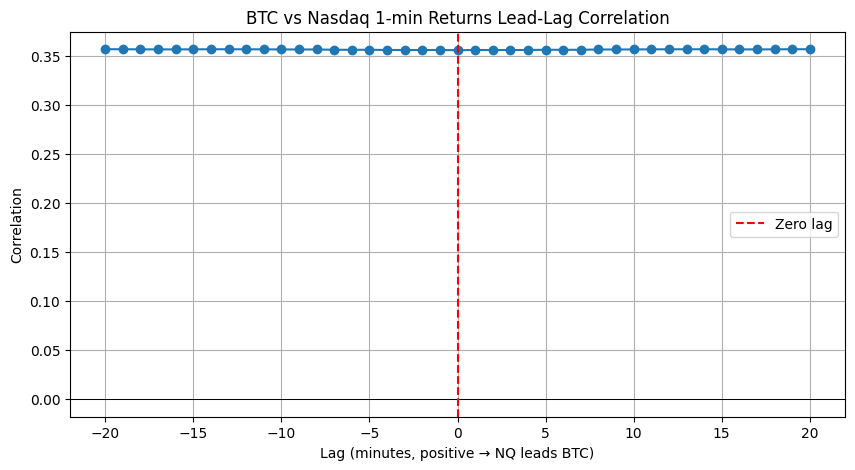

In [48]:
import matplotlib.pyplot as plt
import numpy as np

max_lag = 20  # check +/- 20 minutes

lags = np.arange(-max_lag, max_lag + 1)
corrs = []

for lag in lags:
    if lag < 0:
        # BTC leads NQ
        corr = returns["BTC_return"].iloc[:lag].corr(returns["NQ_return"].iloc[-lag:])
    elif lag > 0:
        # NQ leads BTC
        corr = returns["BTC_return"].iloc[lag:].corr(returns["NQ_return"].iloc[:-lag])
    else:
        # zero lag
        corr = returns["BTC_return"].corr(returns["NQ_return"])
    corrs.append(corr)


plt.figure(figsize=(10,5))
plt.plot(lags, corrs, marker='o')
plt.axhline(0, color='black', linewidth=0.7)
plt.axvline(0, color='red', linestyle='--', label='Zero lag')
plt.title("BTC vs Nasdaq 1-min Returns Lead-Lag Correlation")
plt.xlabel("Lag (minutes, positive → NQ leads BTC)")
plt.ylabel("Correlation")
plt.grid(True)
plt.legend()
plt.show()


In [49]:
# 1-minute volatility (standard deviation of returns)
btc_vol_1min = returns["BTC_return"].std()
nq_vol_1min  = returns["NQ_return"].std()

# Annualized volatility (assuming 252 trading days, 1440 minutes/day)
btc_vol_ann = btc_vol_1min * np.sqrt(252*1440)
nq_vol_ann  = nq_vol_1min  * np.sqrt(252*1440)

print(f"BTC 1-min volatility: {btc_vol_1min:.6f}, annualized: {btc_vol_ann:.2%}")
print(f"NQ 1-min volatility:  {nq_vol_1min:.6f}, annualized: {nq_vol_ann:.2%}")


BTC 1-min volatility: 0.000775, annualized: 46.71%
NQ 1-min volatility:  0.000236, annualized: 14.20%


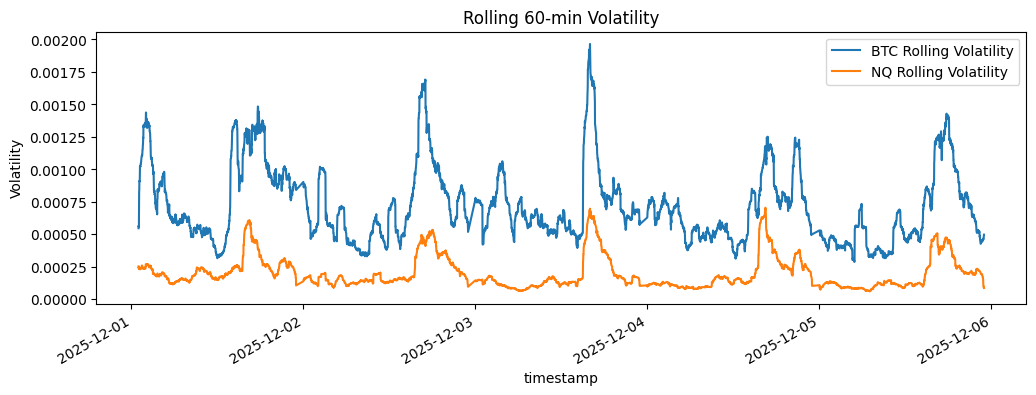

In [50]:
window = 60  # 60 minutes rolling
btc_vol_rolling = returns["BTC_return"].rolling(window).std()
nq_vol_rolling  = returns["NQ_return"].rolling(window).std()

btc_vol_rolling.plot(label='BTC Rolling Volatility', figsize=(12,4))
nq_vol_rolling.plot(label='NQ Rolling Volatility')
plt.title(f"Rolling {window}-min Volatility")
plt.ylabel("Volatility")
plt.legend()
plt.show()


In [51]:
btc_gaps = (returns["BTC_return"].abs() > 0.01).sum()  # arbitrary threshold for large jumps
nq_gaps  = (returns["NQ_return"].abs() > 0.01).sum()
print(f"BTC large jumps (>1%): {btc_gaps}")
print(f"NQ large jumps  (>1%): {nq_gaps}")


BTC large jumps (>1%): 0
NQ large jumps  (>1%): 0


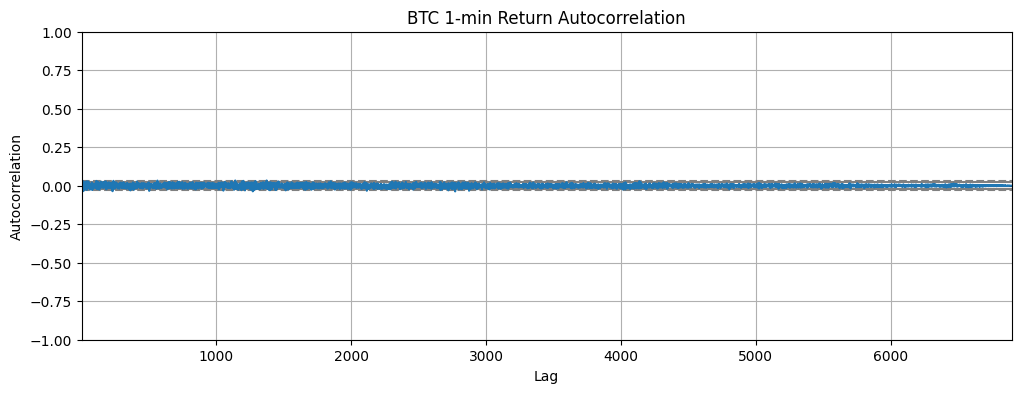

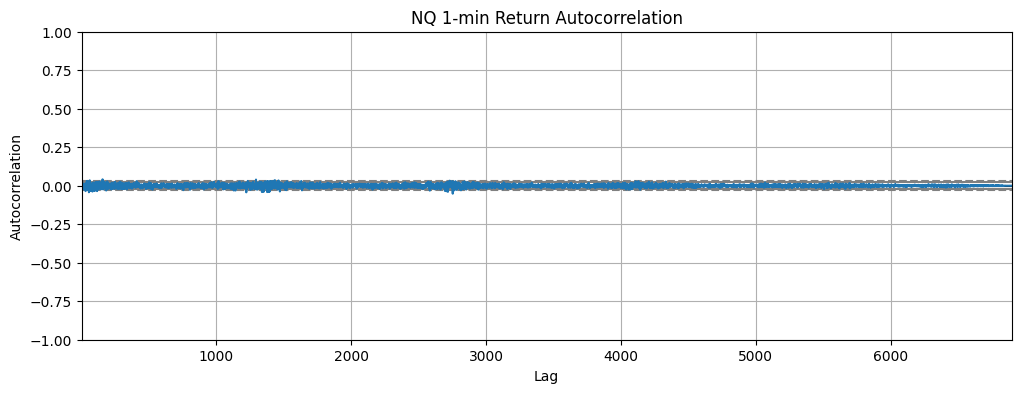

In [52]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(12,4))
autocorrelation_plot(returns["BTC_return"])
plt.title("BTC 1-min Return Autocorrelation")
plt.show()

plt.figure(figsize=(12,4))
autocorrelation_plot(returns["NQ_return"])
plt.title("NQ 1-min Return Autocorrelation")
plt.show()


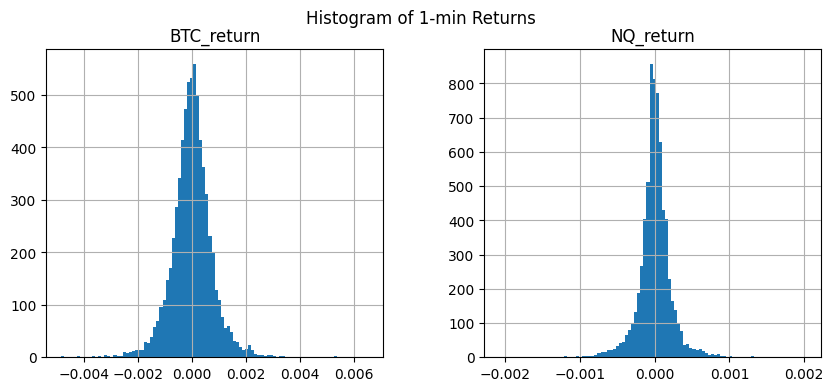

In [53]:
returns.hist(bins=100, figsize=(10,4))
plt.suptitle("Histogram of 1-min Returns")
plt.show()
